<a href="https://colab.research.google.com/github/viklearnsai-hub/Machine_Learning/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Environment Setup


1.   install tensor flow
2.   List item



In [ ]:
!pip install  tensorflow

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("Churn_Modelling.csv")

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
X = df.iloc[:,3:13]

In [ ]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [ ]:
Y = df.iloc[:,13]

In [ ]:
Y.head()

,Exited
0,1
1,0
2,1
3,0
4,0


In [ ]:
geography = pd.get_dummies(X['Geography'],drop_first=True,dtype=int)

In [ ]:
geography.head()

,Germany,Spain
0,0,0
1,0,1
2,0,0
3,0,0
4,0,1


In [ ]:
gender = pd.get_dummies(X['Gender'],drop_first=True,dtype=int)

In [ ]:
gender.head()

,Male
0,0
1,0
2,0
3,0
4,0


In [ ]:
X = X.drop(['Geography','Gender'],axis=1)

In [ ]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10


In [ ]:
X = pd.concat([X,geography,gender],axis=1)

In [ ]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0


In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler


In [ ]:
ss = StandardScaler();
print(X_train)

      CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
9254          686   32       6       0.00              2          1   
1561          632   42       4  119624.60              2          1   
1670          559   24       3  114739.92              1          1   
6087          561   27       9  135637.00              1          1   
6669          517   56       9  142147.32              1          0   
...           ...  ...     ...        ...            ...        ...   
5734          768   54       8   69712.74              1          1   
5191          682   58       1       0.00              1          1   
5390          735   38       1       0.00              3          0   
860           667   43       8  190227.46              1          1   
7270          697   51       1  147910.30              1          1   

      IsActiveMember  EstimatedSalary  Germany  Spain  Male  
9254               1        179093.26        0      0     1  
1561               1   

In [ ]:
X_train = ss.fit_transform(X_train)

In [ ]:
X_test = ss.transform(X_test)

In [ ]:
X_train

array([[ 0.35649971, -0.6557859 ,  0.34567966, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.20389777,  0.29493847, -0.3483691 , ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.96147213, -1.41636539, -0.69539349, ..., -0.57946723,
         1.73494238,  0.91324755],
       ...,
       [ 0.86500853, -0.08535128, -1.38944225, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.15932282,  0.3900109 ,  1.03972843, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [ 0.47065475,  1.15059039, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]])

In [ ]:
X_test

array([[-0.57749609, -0.6557859 , -0.69539349, ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.29729735,  0.3900109 , -1.38944225, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.52560743,  0.48508334, -0.3483691 , ..., -0.57946723,
         1.73494238, -1.09499335],
       ...,
       [ 0.81311987,  0.77030065,  0.69270405, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.41876609, -0.94100321, -0.3483691 , ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.24540869,  0.00972116, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]])

In [ ]:
!pip install tensorflow

In [ ]:
from tensorflow.keras import Sequential #computation by layer by layer
from tensorflow.keras.layers import Dense #Allow adhoc addition,
from tensorflow.keras.layers import ReLU,LeakyReLU,PReLU #activation functions
from tensorflow.keras.layers import Dropout #tackle overfitting, (similar to L1 L2 regularization)

In [ ]:
seq = Sequential()

In [ ]:
seq.add(Dense(units=11,activation='relu'))

In [ ]:
seq.add(Dense(units=7,activation='relu'))

In [ ]:
seq.add(Dense(units=6,activation='relu'))

In [ ]:
seq.add(Dense(units=1,activation='sigmoid'))

In [ ]:
seq.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
import tensorflow

In [ ]:
tensorflow.keras.optimizers.Adam(learning_rate=0.01)

In [ ]:
es = tensorflow.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    mode="auto",
)

In [ ]:
learnhist = seq.fit(X_train,Y_train,batch_size=10,epochs=1000,callbacks=es,validation_split=0.30)

Epoch 1/1000
560/560 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8820 - loss: 0.2961 - val_accuracy: 0.8617 - val_loss: 0.3298
Epoch 2/1000
560/560 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8745 - loss: 0.2947 - val_accuracy: 0.8625 - val_loss: 0.3288
Epoch 3/1000
560/560 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8795 - loss: 0.2957 - val_accuracy: 0.8600 - val_loss: 0.3335
Epoch 4/1000
560/560 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8816 - loss: 0.2945 - val_accuracy: 0.8575 - val_loss: 0.3379
Epoch 5/1000
560/560 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8809 - loss: 0.2924 - val_accuracy: 0.8533 - val_loss: 0.3454
Epoch 6/1000
560/560 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8845 - loss: 0.2881 - val_accuracy: 0.8587 - val_loss: 0.3388
Epoch 7/1000
560/560 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8779 - loss: 0.2884 - val_accuracy: 0.8567 - val_loss: 0.3412
Epoch 8/1000
560/560 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8847 - loss: 0.2896 - 

In [ ]:
learnhist.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

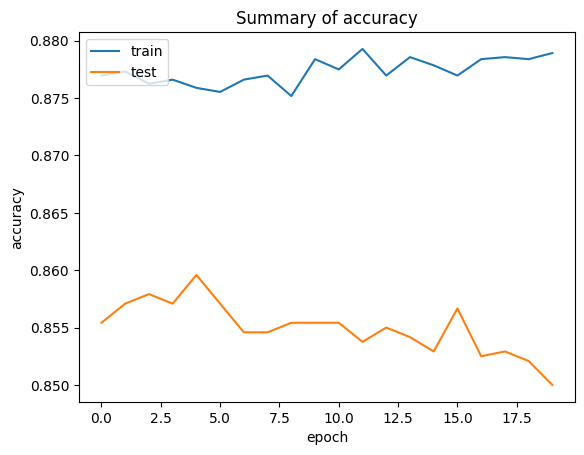

In [ ]:
import matplotlib.pyplot as plt
plt.plot(learnhist.history['accuracy'])
plt.plot(learnhist.history['val_accuracy'])
plt.title('Summary of accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
y_pred = seq.predict(X_test)
y_pred = (y_pred > 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm = confusion_matrix(Y_test,y_pred)
score = accuracy_score(Y_test,y_pred)

In [ ]:
seq.get_weights()

[array([[-0.16678691, -0.06412364,  0.22895487, -0.3593055 , -0.0663569 ,
         -0.0609969 , -0.5675952 ,  0.22978476, -0.17207721, -0.02694487,
          0.05205515],
        [-0.1898281 ,  0.7138933 ,  0.36869135, -0.77190673, -0.24290997,
         -0.7475782 ,  0.19945735, -1.1674058 ,  0.33304414,  1.6621128 ,
          0.09575908],
        [ 0.24150164,  1.0117397 , -0.04727989, -0.5334204 , -0.22209404,
         -0.26146522, -1.1138678 , -0.07496705,  0.28665963, -0.11000283,
          0.1231047 ],
        [-0.6253145 , -0.45102197, -0.10548019,  0.16101654, -1.0366117 ,
          0.72693163,  0.22390014, -0.17030923,  0.78401226, -0.2974407 ,
         -1.3435762 ],
        [-0.7630655 , -0.66762036, -0.94394314,  0.27419853,  1.3687276 ,
          0.15288785,  0.32962337,  0.3631906 ,  1.0229521 , -0.252647  ,
         -0.22286509],
        [-0.16239068,  0.48396808, -0.15346913,  0.8394164 ,  0.23244268,
         -0.7363431 ,  0.5437872 , -0.28040197, -0.29113498, -0.2717545